# Basic project house price prediction

In [1]:
from sklearn.datasets import fetch_california_housing

Importing library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score
)

Loading Dataset

In [3]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns= housing.feature_names)
y = pd.Series(housing.target, name= "MedHouseVal")

In [4]:
df = pd.concat([X, y], axis= 1)

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Understand the data first

In [6]:
df.shape

(20640, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## Visualizing the data

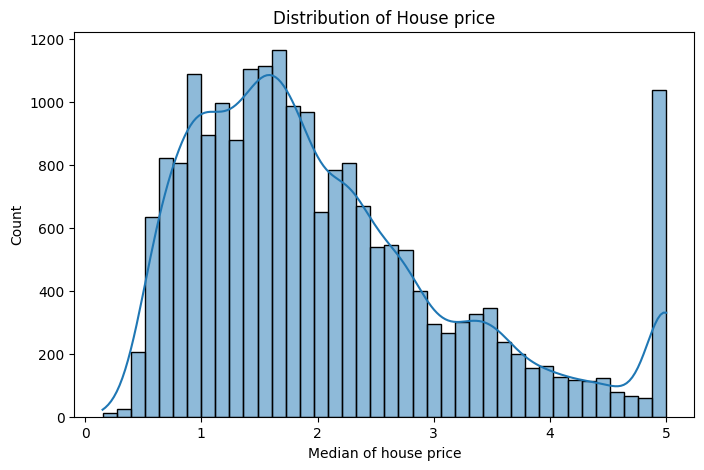

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df.MedHouseVal, bins= 40, kde= True)
plt.title("Distribution of House price")
plt.xlabel("Median of house price")
plt.ylabel("Count")
plt.show()

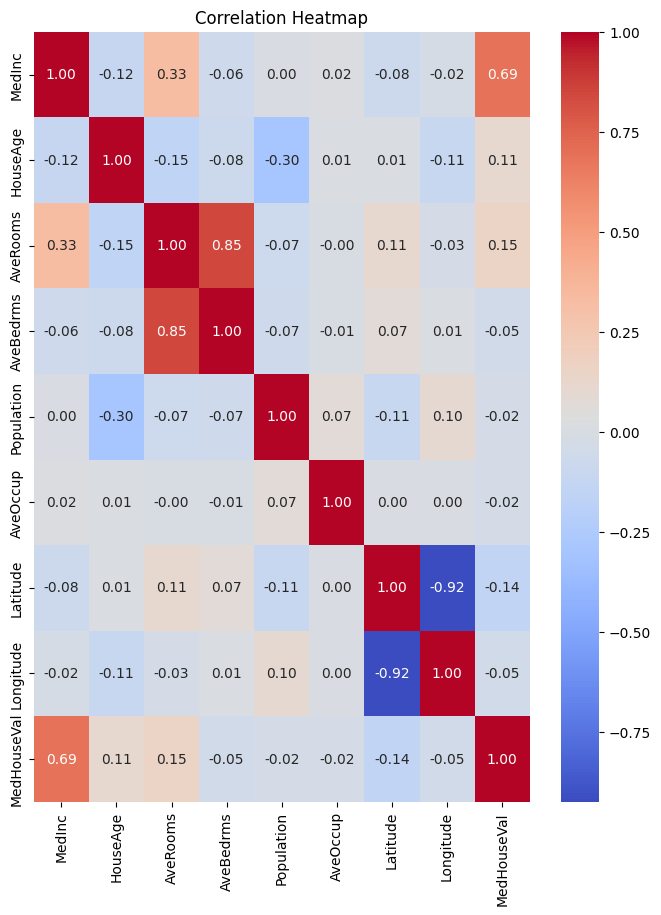

In [11]:
plt.figure(figsize=(8, 10))
sns.heatmap(df.corr(), annot= True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

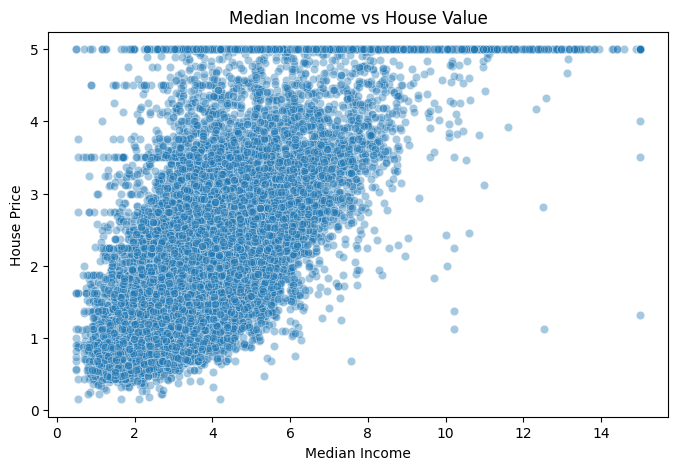

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="MedInc", y= "MedHouseVal", alpha =0.4)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

Prepairing X and y

In [13]:
X = df.drop("MedHouseVal", axis= 1)
y = df.MedHouseVal

Train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Evaluation function

In [23]:
def evaluation(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(root_mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"Mean absolute error: {mae}")
    print(f"Root Mean Square Error: {rmse}")
    print(f"R2: {r2}")
    print("-"*30)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_result = evaluation(y_test, y_pred_linear, "Linear Regression")


Model: Linear Regression
Mean absolute error: 0.5332001304956564
Root Mean Square Error: 0.8634705455386283
R2: 0.5757877060324508
------------------------------


## Ridge

In [25]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_results = evaluation(y_test, y_pred_ridge, "Ridge" )

Model: Ridge
Mean absolute error: 0.5331931195789734
Root Mean Square Error: 0.8634562781527956
R2: 0.5758157428913684
------------------------------


Ridge Regression, also known as L2 regulazation, is a technique used in machine learning to prevent overfitting and address multicollinearity among
predictor variables in linear regression models.

## Lasso

In [26]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_results = evaluation(y_test, y_pred_lasso, "Lasso")

Model: Lasso
Mean absolute error: 0.6222011605619466
Root Mean Square Error: 0.9079626423398967
R2: 0.48136113250290735
------------------------------


## Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_results = evaluation(y_test, y_pred_rf, "Random Forest Regressor")

Model: Random Forest Regressor
Mean absolute error: 0.3272511930717056
Root Mean Square Error: 0.7095410443505404
R2: 0.8065791749484683
------------------------------


### Comparing All Model to each other

In [28]:
results_df = pd.DataFrame([
    linear_result,
    ridge_results,
    lasso_results,
    rf_results
])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.533200,0.863471,0.575788
1,Ridge,0.533193,0.863456,0.575816
2,Lasso,0.622201,0.907963,0.481361
3,Random Forest Regressor,0.327251,0.709541,0.806579


## Visualize Model Performance

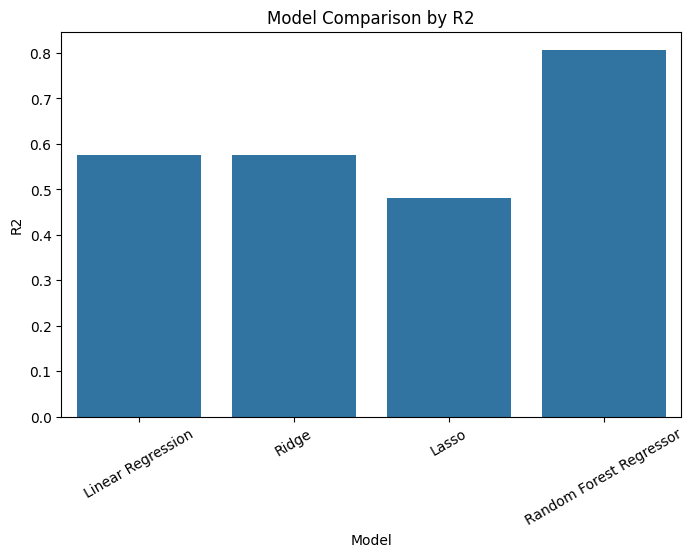

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data= results_df, x="Model", y="R2")
plt.title("Model Comparison by R2")
plt.xticks(rotation=30)
plt.show()

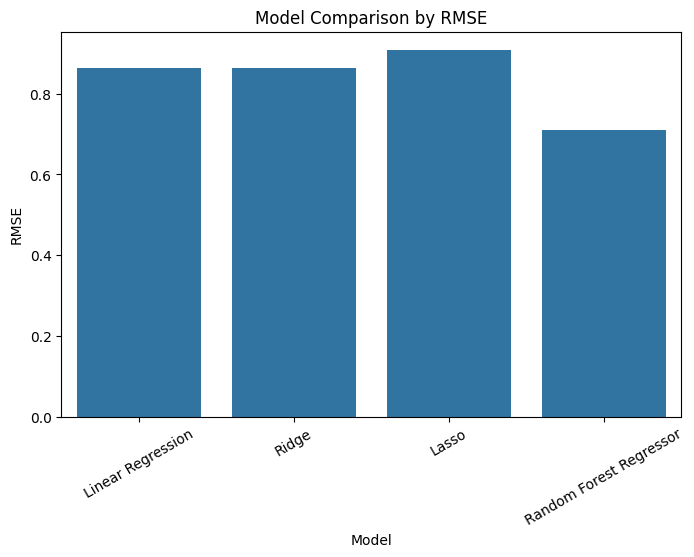

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=30)
plt.show()

### Actual vs predicted

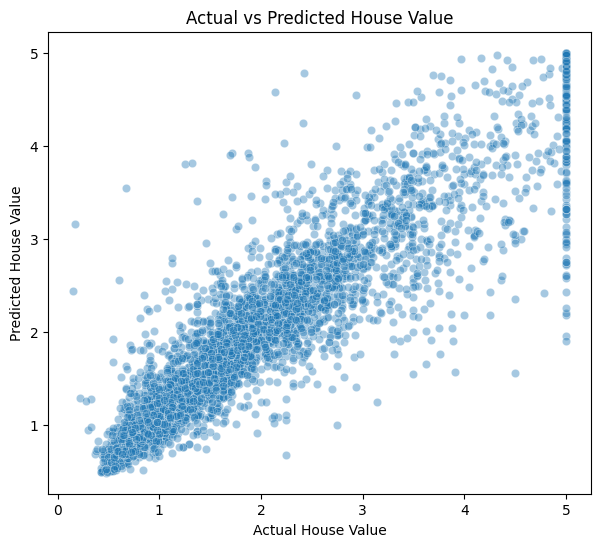

In [32]:
plt.figure(figsize= (7, 6))
sns.scatterplot(x = y_test, y=y_pred_rf, alpha= 0.4)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Value")
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,MedInc,0.525116
5,AveOccup,0.138854
7,Longitude,0.089044
6,Latitude,0.088246
1,HouseAge,0.054263
2,AveRooms,0.044232
4,Population,0.030875
3,AveBedrms,0.029370


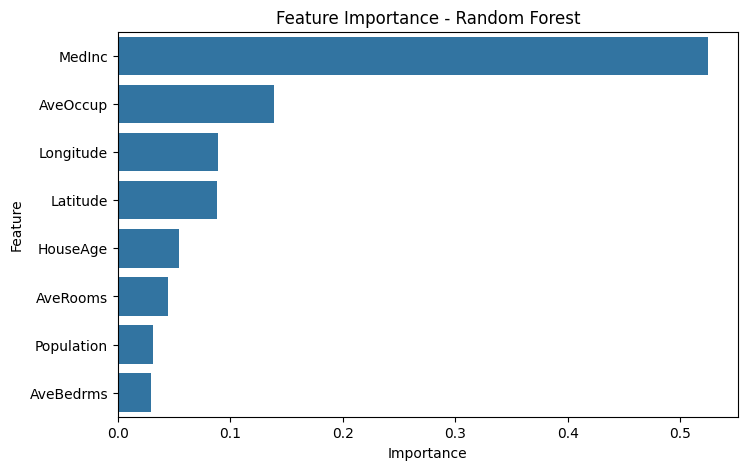

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

##  House Price Prediction Project

In this project, I built several regression models to predict California house prices.

###  Models Tested
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor

###  Key Insight
Random Forest performed the best because it can capture **non-linear relationships** in the data.

###  Important Feature
The most important feature was **MedInc** (Median Income), meaning income strongly affects house value.

###  Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (R-squared)